## Pricipal Component Analysis & Random Matrix Theory

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from QuantLib import min_max_norm as mmnorm, standar_norm as stdnorm
#Importamos datos de IPC
ipc_df = pd.read_csv('ipc_data.csv')
ipc_df['Date'] = pd.to_datetime(ipc_df['Date'])
ipc_df.set_index('Date', inplace=True)
ipc_df = ipc_df.rename(columns={'Promotora Infraestructura': 'Pinfra'})
# Mostrar las primeras filas y la información general del DataFrame
ipc_df.info(), ipc_df.head()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 6514 entries, 2000-01-03 06:00:00 to 2025-08-29 06:00:00
Data columns (total 36 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Alfa                6514 non-null   float64
 1   Alsea               6503 non-null   float64
 2   América Móvil       6514 non-null   float64
 3   Arca Continental    5762 non-null   float64
 4   Banco del Bajío     2071 non-null   float64
 5   Becle               2152 non-null   float64
 6   BMV                 4323 non-null   float64
 7   Cemex               6514 non-null   float64
 8   Coca-Cola Femsa     1608 non-null   float64
 9   Volaris             2993 non-null   float64
 10  Vesta               3293 non-null   float64
 11  FEMSA               6514 non-null   float64
 12  Genomma Lab         4320 non-null   float64
 13  Gentera             3683 non-null   float64
 14  Gruma               6495 non-null   float64
 15  GAP Centro Norte   

(None,
                          Alfa  Alsea  América Móvil  Arca Continental  \
 Date                                                                    
 2000-01-03 06:00:00  3.349844    NaN       8.708057               NaN   
 2000-01-04 06:00:00  3.135697    NaN       8.088385               NaN   
 2000-01-05 06:00:00  3.196882    NaN       8.088385               NaN   
 2000-01-06 06:00:00  3.059217    NaN       8.153611               NaN   
 2000-01-07 06:00:00  3.365139    NaN       8.186223               NaN   
 
                      Banco del Bajío  Becle  BMV     Cemex  Coca-Cola Femsa  \
 Date                                                                          
 2000-01-03 06:00:00              NaN    NaN  NaN  6.416358              NaN   
 2000-01-04 06:00:00              NaN    NaN  NaN  5.972150              NaN   
 2000-01-05 06:00:00              NaN    NaN  NaN  5.996828              NaN   
 2000-01-06 06:00:00              NaN    NaN  NaN  5.898115              

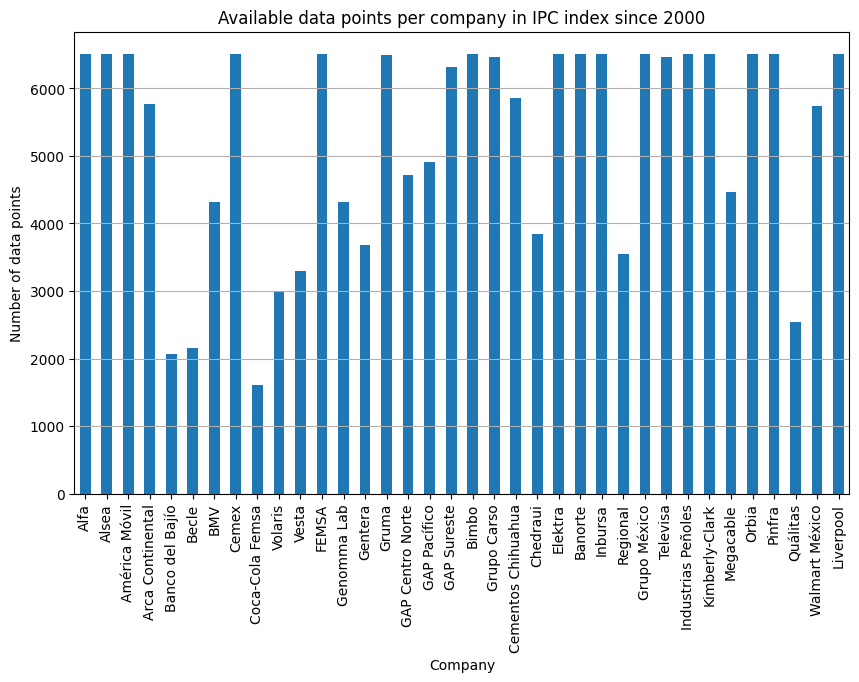

In [2]:
# Contar el número de datos no nulos por empresa
conteo_datos = ipc_df.notnull().sum()
# Crear el histograma
plt.figure(figsize=(10, 6))
conteo_datos.plot(kind='bar')
plt.title('Available data points per company in IPC index since 2000')
plt.xlabel('Company')
plt.ylabel('Number of data points')
plt.xticks(rotation=90)
plt.grid(axis='y')
plt.show()

In [3]:
conteo_datos

Alfa                  6514
Alsea                 6503
América Móvil         6514
Arca Continental      5762
Banco del Bajío       2071
Becle                 2152
BMV                   4323
Cemex                 6514
Coca-Cola Femsa       1608
Volaris               2993
Vesta                 3293
FEMSA                 6514
Genomma Lab           4320
Gentera               3683
Gruma                 6495
GAP Centro Norte      4711
GAP Pacífico          4909
GAP Sureste           6317
Bimbo                 6514
Grupo Carso           6464
Cementos Chihuahua    5859
Chedraui              3850
Elektra               6514
Banorte               6514
Inbursa               6514
Regional              3547
Grupo México          6514
Televisa              6458
Industrias Peñoles    6512
Kimberly-Clark        6514
Megacable             4472
Orbia                 6514
Pinfra                6514
Quálitas              2547
Walmart México        5732
Liverpool             6511
dtype: int64

- Eliminar las columnas con muchos valores faltantes (para PCA/RMT es mejor trabajar con datos completos).

- Interpolar o eliminar filas con valores NaN.

- Calcular los retornos logarítmicos.

- Estandarizar (opcional pero útil).

- Obtener la matriz de correlación para análisis con PCA y RMT.

#### Matriz de correlación

In [3]:
#Eliminar columnas con más del 10% de valores faltantes
threshold = .9 * len(ipc_df)
filtered_df = ipc_df.dropna(axis=1, thresh=threshold)

# Eliminar filas con valores faltantes restantes
filtered_df = filtered_df.dropna()
filtered_df

,Alfa,Alsea,América Móvil,Cemex,FEMSA,Gruma,GAP Sureste,Bimbo,Grupo Carso,Elektra,Banorte,Inbursa,Grupo México,Televisa,Industrias Peñoles,Kimberly-Clark,Orbia,Pinfra,Liverpool
Date,,,,,,,,,,,,,,,,,,,
2000-10-04 05:00:00,1.417073,1.451002,4.076806,5.204373,7.800539,5.374216,5.829368,3.020874,3.608135,41.976585,1.505608,5.195737,1.633806,21.339062,6.624062,2.138059,0.721078,0.430400,11.324288
2000-10-05 05:00:00,1.417073,1.451002,4.076806,5.204373,7.800539,5.347477,5.829368,3.020874,3.080115,41.976585,1.505608,5.195737,1.633806,18.418255,6.567926,2.138059,0.721078,0.430400,11.324288
2000-10-06 05:00:00,1.385584,1.451002,4.027886,5.172326,7.682024,5.347477,5.692742,3.047914,3.080115,40.952778,1.481324,5.073711,1.579646,18.418255,6.567926,2.229040,0.721078,0.415299,11.324288
2000-10-09 05:00:00,1.322602,1.451002,3.897425,5.101823,7.628155,5.347477,5.692742,3.047914,3.080115,40.099579,1.493467,5.009488,1.534514,18.418255,6.567926,2.229040,0.721078,0.339790,11.324288
2000-10-10 05:00:00,1.258047,1.451002,3.913733,4.986456,7.789768,5.347477,5.692742,3.047914,3.080115,40.952778,1.493467,4.945262,1.541283,18.418255,6.567926,2.233590,0.721078,0.309586,11.324288
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-08-25 06:00:00,14.090000,54.630001,18.750000,16.510000,164.839996,325.929993,602.739990,58.820000,126.070000,370.109985,166.039993,48.810001,125.000000,9.250000,531.900024,35.970001,13.320000,234.119995,91.239998
2025-08-26 06:00:00,13.990000,53.919998,18.670000,16.719999,162.470001,320.600006,609.239990,58.110001,122.320000,376.880005,165.990005,49.049999,124.400002,9.230000,534.510010,34.400002,14.000000,234.580002,91.339996
2025-08-27 06:00:00,14.190000,55.869999,18.620001,16.650000,162.360001,324.000000,612.229980,58.349998,123.930000,376.790009,168.490005,48.910000,124.820000,9.980000,566.929993,35.689999,13.740000,233.789993,91.190002


In [4]:

# Calcular retornos logarítmicos
log_returns = np.log(filtered_df / filtered_df.shift(1)).dropna()

#Estandarizar retornos
standardized_returns = (log_returns - log_returns.mean()) / log_returns.std()
standardized_returns


,Alfa,Alsea,América Móvil,Cemex,FEMSA,Gruma,GAP Sureste,Bimbo,Grupo Carso,Elektra,Banorte,Inbursa,Grupo México,Televisa,Industrias Peñoles,Kimberly-Clark,Orbia,Pinfra,Liverpool
Date,,,,,,,,,,,,,,,,,,,
2000-10-05 05:00:00,-0.015811,-0.026391,-0.010538,-0.007585,-0.029036,-0.237791,-0.018915,-0.024857,-7.181406,-0.012823,-0.033524,-0.017170,-0.028616,-6.778209,-0.325889,-0.026521,-0.019717,-0.043721,-0.015505
2000-10-06 05:00:00,-0.994368,-0.026391,-0.539161,-0.258571,-0.954812,-0.027321,-0.628821,0.448403,-0.025334,-0.929159,-0.761937,-1.164871,-1.440112,0.005286,-0.025256,2.466948,-0.019717,-1.609441,-0.015505
2000-10-09 05:00:00,-2.041534,-0.026391,-1.452313,-0.565276,-0.454565,-0.027321,-0.018915,-0.024857,-0.025334,-0.794133,0.332180,-0.632359,-1.242301,0.005286,-0.025256,-0.026521,-0.019717,-8.840230,-0.015505
2000-10-10 05:00:00,-2.194837,-0.026391,0.172311,-0.936993,1.238717,-0.027321,-0.018915,-0.024857,-0.025334,0.768488,-0.033524,-0.640315,0.155685,0.005286,-0.025256,0.095505,-0.019717,-4.124399,-0.015505
2000-10-11 05:00:00,1.113880,-0.026391,-0.561334,-0.533262,-0.617365,-0.027321,-0.018915,-0.975646,-0.025334,-1.592226,-1.514511,-1.159477,1.000769,0.005286,-0.025256,-5.778183,-0.019717,-0.043721,-0.015505
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-08-25 06:00:00,-0.200845,-0.546817,0.036196,-0.056780,-0.285278,-0.598275,-0.437038,0.364804,-0.304295,-0.100954,-0.862164,0.032328,-0.857751,0.355359,-2.228991,-0.076402,0.198033,-0.312514,0.163901
2025-08-26 06:00:00,-0.325962,-0.629670,-0.197770,0.506004,-0.904751,-0.723083,0.256929,-0.669795,-1.391055,0.659860,-0.047012,0.219699,-0.230075,-0.094466,0.147654,-2.696887,2.037929,0.042324,0.035627
2025-08-27 06:00:00,0.602295,1.611931,-0.127964,-0.178061,-0.069991,0.417828,0.106986,0.194026,0.566075,-0.021685,0.636125,-0.155203,0.112507,3.605592,2.054827,2.176246,-0.794416,-0.191597,-0.092221


In [5]:


# Calcular la matriz de correlación
corr_matrix = standardized_returns.corr()

# Mostrar los nombres de las columnas seleccionadas y la matriz de correlación
filtered_df.columns.tolist()
corr_matrix.head(20)

,Alfa,Alsea,América Móvil,Cemex,FEMSA,Gruma,GAP Sureste,Bimbo,Grupo Carso,Elektra,Banorte,Inbursa,Grupo México,Televisa,Industrias Peñoles,Kimberly-Clark,Orbia,Pinfra,Liverpool
Alfa,1.000000,0.229695,0.147135,0.333543,0.305398,0.138465,0.073910,0.297407,0.253442,0.168568,0.302602,0.287116,0.304455,0.293702,0.212014,0.253869,0.260124,0.188080,0.152666
Alsea,0.229695,1.000000,0.117959,0.277548,0.249151,0.105010,0.097520,0.208484,0.201388,0.107162,0.306772,0.211499,0.226157,0.216051,0.181625,0.208361,0.227373,0.175213,0.133350
América Móvil,0.147135,0.117959,1.000000,0.175068,0.200220,0.049202,0.060325,0.145838,0.070863,0.103466,0.164525,0.128056,0.162036,0.190554,0.124179,0.118706,0.096296,0.073900,0.043353
Cemex,0.333543,0.277548,0.175068,1.000000,0.346982,0.169569,0.120975,0.285975,0.269579,0.149415,0.398151,0.287648,0.386050,0.372337,0.246123,0.274113,0.277371,0.206005,0.102697
FEMSA,0.305398,0.249151,0.200220,0.346982,1.000000,0.110511,0.101535,0.285710,0.203769,0.156405,0.353374,0.243890,0.293073,0.344708,0.198901,0.273591,0.207737,0.206538,0.142023
Gruma,0.138465,0.105010,0.049202,0.169569,0.110511,1.000000,0.044622,0.157685,0.179349,0.070923,0.148787,0.109260,0.128769,0.121147,0.079513,0.062985,0.140360,0.083545,0.052093
GAP Sureste,0.073910,0.097520,0.060325,0.120975,0.101535,0.044622,1.000000,0.074257,0.104203,0.048734,0.107209,0.080903,0.097050,0.097878,0.050457,0.097824,0.030662,0.081527,0.056015
Bimbo,0.297407,0.208484,0.145838,0.285975,0.285710,0.157685,0.074257,1.000000,0.302302,0.168644,0.286338,0.327793,0.279853,0.272830,0.242541,0.300468,0.218013,0.192016,0.150020
Grupo Carso,0.253442,0.201388,0.070863,0.269579,0.203769,0.179349,0.104203,0.302302,1.000000,0.109477,0.253502,0.329623,0.247991,0.236993,0.243001,0.220848,0.216235,0.183747,0.089313
Elektra,0.168568,0.107162,0.103466,0.149415,0.156405,0.070923,0.048734,0.168644,0.109477,1.000000,0.155439,0.150468,0.137792,0.152676,0.115395,0.120329,0.098201,0.095709,0.047302


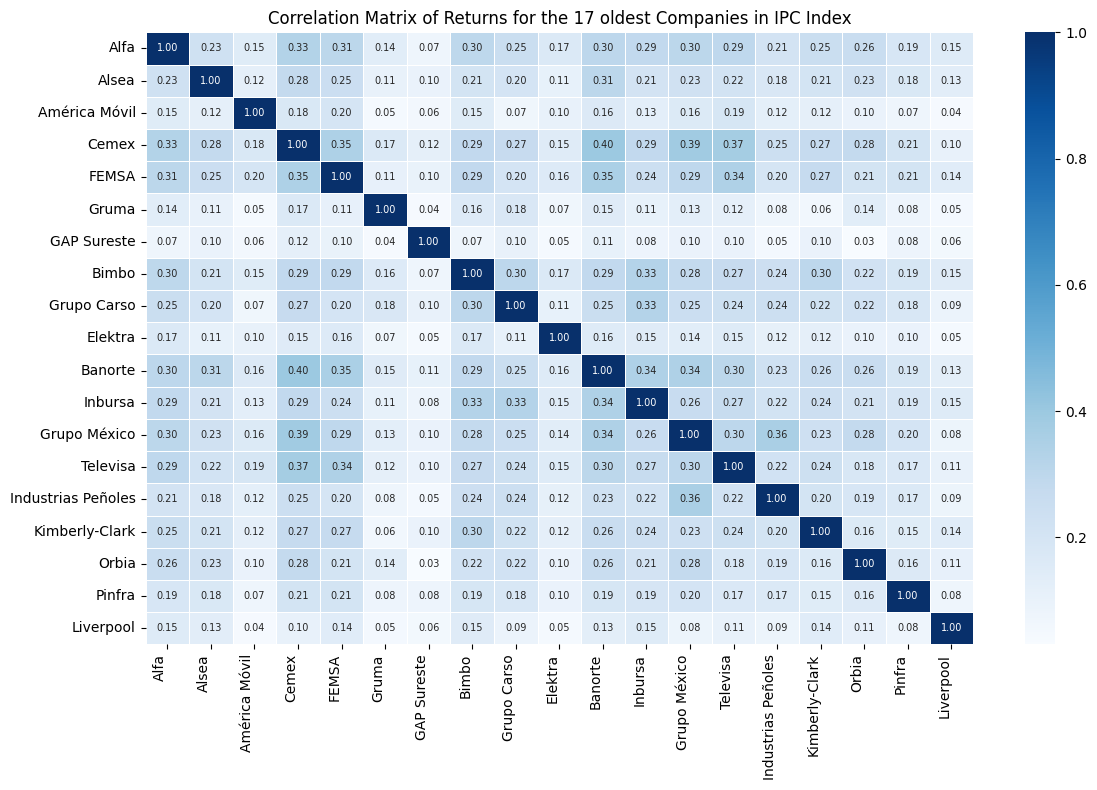

In [6]:
# Visualizar la matriz de correlación
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='Blues', fmt=".2f", linewidths=.5, annot_kws={"size": 7})
plt.title('Correlation Matrix of Returns for the 17 oldest Companies in IPC Index')
plt.xticks(rotation=90, ha="right", fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.show()

In [7]:
standardized_returns.head(5)

,Alfa,Alsea,América Móvil,Cemex,FEMSA,Gruma,GAP Sureste,Bimbo,Grupo Carso,Elektra,Banorte,Inbursa,Grupo México,Televisa,Industrias Peñoles,Kimberly-Clark,Orbia,Pinfra,Liverpool
Date,,,,,,,,,,,,,,,,,,,
2000-10-05 05:00:00,-0.015811,-0.026391,-0.010538,-0.007585,-0.029036,-0.237791,-0.018915,-0.024857,-7.181406,-0.012823,-0.033524,-0.017170,-0.028616,-6.778209,-0.325889,-0.026521,-0.019717,-0.043721,-0.015505
2000-10-06 05:00:00,-0.994368,-0.026391,-0.539161,-0.258571,-0.954812,-0.027321,-0.628821,0.448403,-0.025334,-0.929159,-0.761937,-1.164871,-1.440112,0.005286,-0.025256,2.466948,-0.019717,-1.609441,-0.015505
2000-10-09 05:00:00,-2.041534,-0.026391,-1.452313,-0.565276,-0.454565,-0.027321,-0.018915,-0.024857,-0.025334,-0.794133,0.332180,-0.632359,-1.242301,0.005286,-0.025256,-0.026521,-0.019717,-8.840230,-0.015505
2000-10-10 05:00:00,-2.194837,-0.026391,0.172311,-0.936993,1.238717,-0.027321,-0.018915,-0.024857,-0.025334,0.768488,-0.033524,-0.640315,0.155685,0.005286,-0.025256,0.095505,-0.019717,-4.124399,-0.015505
2000-10-11 05:00:00,1.113880,-0.026391,-0.561334,-0.533262,-0.617365,-0.027321,-0.018915,-0.975646,-0.025334,-1.592226,-1.514511,-1.159477,1.000769,0.005286,-0.025256,-5.778183,-0.019717,-0.043721,-0.015505


Text(0.5, 1.0, 'Retornos estandarizados de Cemex Vs Banorte')

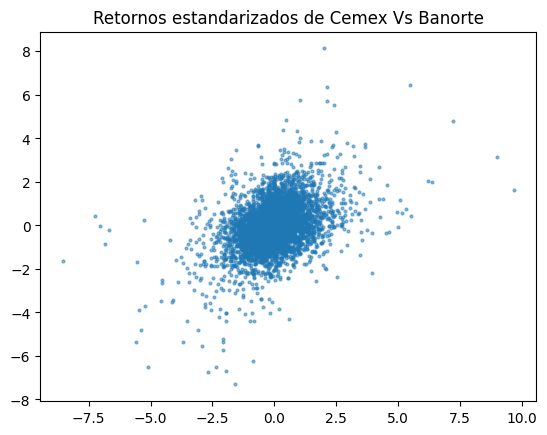

In [11]:
plt.plot(standardized_returns['Cemex'],standardized_returns['Banorte'], 'o', markersize=2, alpha=0.5)#,edgecolor='black')
plt.title('Retornos estandarizados de Cemex Vs Banorte')

### Calculo de Eigenvalores y eigenvectores con numpy

In [12]:
# Obtener autovalores y autovectores de la matriz de correlación
eigenvalues, eigenvectors = np.linalg.eigh(corr_matrix)

# Ordenarlos de mayor a menor
idx = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

# Calcular la varianza explicada
explained_variance = eigenvalues / np.sum(eigenvalues)
# Calcular la varianza acumulada
cumulative_variance = np.cumsum(explained_variance)
# Mostrar la varianza explicada y acumulada
#explained_variance#, cumulative_variance
#eigenvalues

In [13]:
eigenvalues

array([4.65626667, 1.05575807, 1.01994985, 0.98383396, 0.95876939,
       0.94516113, 0.89159619, 0.85462019, 0.84924957, 0.80904339,
       0.78157433, 0.76638021, 0.70059053, 0.67973996, 0.66067595,
       0.64383668, 0.61304391, 0.57402949, 0.55588055])

In [14]:
eigenvectors[:, :3] # Mostrar los primeros 5 autovectores


array([[ 0.27220049, -0.01702427, -0.00932317],
       [ 0.22715942, -0.00948468, -0.12752893],
       [ 0.1455722 ,  0.57582297,  0.16839999],
       [ 0.30185207,  0.08007066,  0.12638719],
       [ 0.27329856,  0.26308699, -0.04989195],
       [ 0.13045612, -0.41877209,  0.19317112],
       [ 0.09371924,  0.20610796, -0.44180702],
       [ 0.27015718, -0.11636666, -0.0770009 ],
       [ 0.24228037, -0.36517635,  0.00244361],
       [ 0.1430717 ,  0.21238393,  0.09180976],
       [ 0.29345746,  0.04906116,  0.01170444],
       [ 0.26344076, -0.15315235, -0.1216124 ],
       [ 0.28171011,  0.02184443,  0.26307628],
       [ 0.26684071,  0.22547664,  0.06921875],
       [ 0.22343339, -0.06436558,  0.2352167 ],
       [ 0.23421304,  0.0823814 , -0.24841687],
       [ 0.22085548, -0.25621305,  0.16282025],
       [ 0.18538855, -0.11756365, -0.02606527],
       [ 0.12387094, -0.12245037, -0.67587032]])

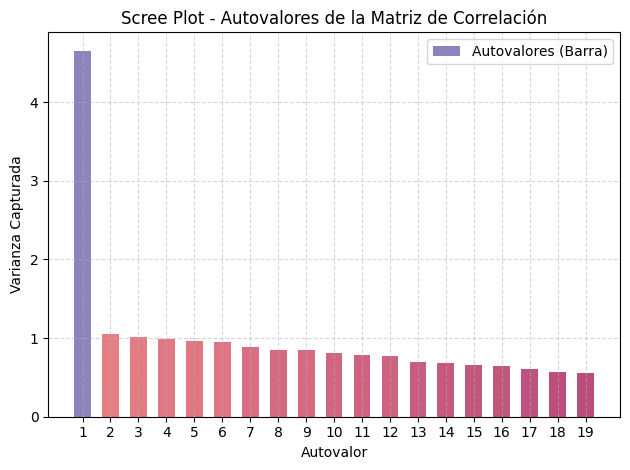

In [15]:
import matplotlib.cm as cm
# Crear etiquetas para las barras
labels = list(range(1, len(eigenvalues) + 1))
# Normalizar los valores para que estén entre 0 y 1
norm = plt.Normalize(eigenvalues.min(), eigenvalues.max())
# Obtener un mapa de colores
colors = cm.Spectral(norm(eigenvalues))
#colors = ['red', 'blue', 'green', 'orange', 'purple', 'cyan', 'magenta', 'yellow', 'black', 'pink', 'brown', 'gray']
# Graficar Scree plot (autovalores)
plt.figure()
#plt.plot(range(1, len(eigenvalues)+1), eigenvalues, marker='o', label='Autovalores')
plt.bar(labels,eigenvalues, color=colors, alpha=0.7, width=0.6, label='Autovalores (Barra)')
plt.xticks(range(1, len(eigenvalues)+1), labels)
plt.title('Scree Plot - Autovalores de la Matriz de Correlación')
plt.ylabel('Varianza Capturada')
plt.xlabel('Autovalor')
plt.grid(True, linestyle='--', alpha=0.5)
#plt.axhline(y=1, color='red', linestyle='--', label='Línea de Referencia (1)')
plt.legend()
plt.tight_layout()
plt.show()


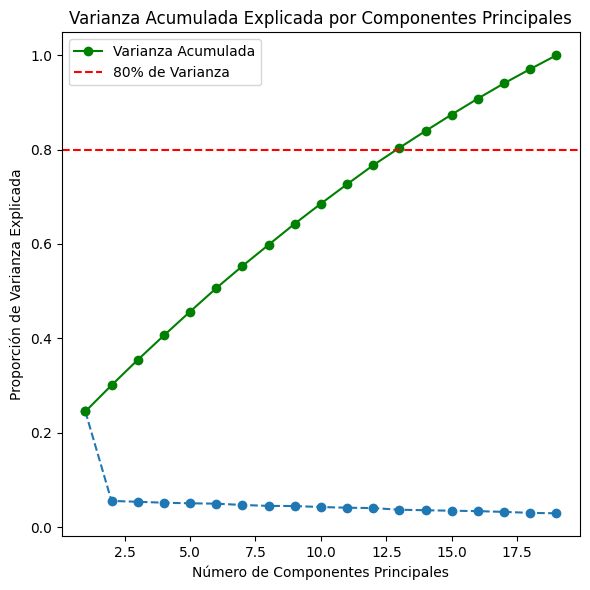

In [16]:


# Graficar la varianza explicada
plt.figure(figsize=(6, 6))
plt.plot(range(1, len(explained_variance) + 1), explained_variance, marker='o', linestyle='--')
plt.title('Varianza Explicada por Componente Principal')
plt.xlabel('Número de Componente Principal')
plt.ylabel('Porcentaje de Varianza Explicada')

plt.plot(range(1, len(eigenvalues)+1), cumulative_variance, marker='o', color='green', label='Varianza Acumulada')
plt.axhline(y=0.8, color='red', linestyle='--', label='80% de Varianza')
plt.title('Varianza Acumulada Explicada por Componentes Principales')
plt.xlabel('Número de Componentes Principales')
plt.ylabel('Proporción de Varianza Explicada')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.grid()
plt.show()

### Calculo de PCA con ScikitLEarn
- Proyeccion de los datos sobre los componentes principales 

In [8]:
from sklearn.decomposition import PCA

# Aplicar PCA a los datos estandarizados
pca = PCA()
pca.fit(standardized_returns)

# Proyección de los datos sobre los primeros componentes principales
projected_data = pca.transform(standardized_returns)

# Crear un DataFrame con los dos primeros componentes para visualización
pca_df = pd.DataFrame(projected_data[:, :2], columns=['PC1', 'PC2'], index=standardized_returns.index)

# Crear un DataFrame para los pesos de los componentes (autovectores)
loadings = pd.DataFrame(pca.components_.T, 
                        columns=[f'PC{i+1}' for i in range(len(pca.components_))],
                        index=standardized_returns.columns)

# Mostrar los primeros valores proyectados y las cargas de los componentes principales
#pca_df.head(), 
sort_loadings = loadings.sort_values(by='PC1', ascending=False)
loadings

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13,PC14,PC15,PC16,PC17,PC18,PC19
Alfa,0.272200,-0.017024,0.009323,-0.109263,0.107960,-0.052861,0.037578,-0.086447,-0.024930,-0.095948,-0.273259,0.263602,-0.416375,0.732327,-0.000850,0.068496,-0.084159,-0.105068,-0.061539
Alsea,0.227159,-0.009485,0.127529,0.032472,-0.132872,-0.317312,0.282176,-0.142306,-0.155055,0.362363,0.551073,-0.283274,-0.321428,0.091291,0.100035,-0.157722,-0.008580,0.157742,0.044841
América Móvil,0.145572,0.575823,-0.168400,-0.009230,0.175415,-0.173115,-0.246731,0.447202,0.285460,0.421720,0.054339,0.101210,-0.012819,0.030667,-0.130657,0.023907,0.072686,-0.016764,-0.018563
Cemex,0.301852,0.080071,-0.126387,0.102482,-0.069311,-0.165124,-0.017319,-0.182278,-0.078259,-0.154766,-0.113705,-0.050179,0.085152,-0.034677,-0.250329,-0.168570,0.417814,-0.264923,0.648531
FEMSA,0.273299,0.263087,0.049892,-0.035898,0.033437,-0.159216,0.036441,-0.187853,0.152296,-0.254812,0.011045,-0.008998,0.036144,-0.166163,0.389505,0.633904,-0.140624,0.231451,0.212357
Gruma,0.130456,-0.418772,-0.193171,0.421649,0.513111,-0.285809,-0.169451,0.172684,0.099907,-0.236826,0.255753,-0.028723,0.114465,0.076240,-0.064663,-0.017802,-0.168011,0.070748,0.007545
GAP Sureste,0.093719,0.206108,0.441807,0.758695,-0.166543,0.141727,-0.005032,0.138937,-0.223907,0.037801,-0.135177,0.143037,0.009928,0.019105,0.099662,-0.028824,-0.093064,-0.023833,0.004629
Bimbo,0.270157,-0.116367,0.077001,-0.114151,0.156211,0.242660,-0.192484,-0.003891,0.139136,0.049896,0.122194,0.209594,0.044369,-0.069500,0.685943,-0.360676,0.249995,-0.153453,-0.002012
Grupo Carso,0.242280,-0.365176,-0.002444,0.135368,-0.001385,0.292680,-0.221881,-0.045307,0.076516,0.287594,-0.061072,-0.098712,-0.364399,-0.216732,-0.196702,0.434073,0.355483,-0.004015,-0.131816
Elektra,0.143072,0.212384,-0.091810,-0.040106,0.577482,0.435612,0.518890,0.060347,-0.320947,-0.007845,0.044494,-0.043812,0.011984,-0.093663,-0.093527,0.030532,0.048980,0.016733,0.003423


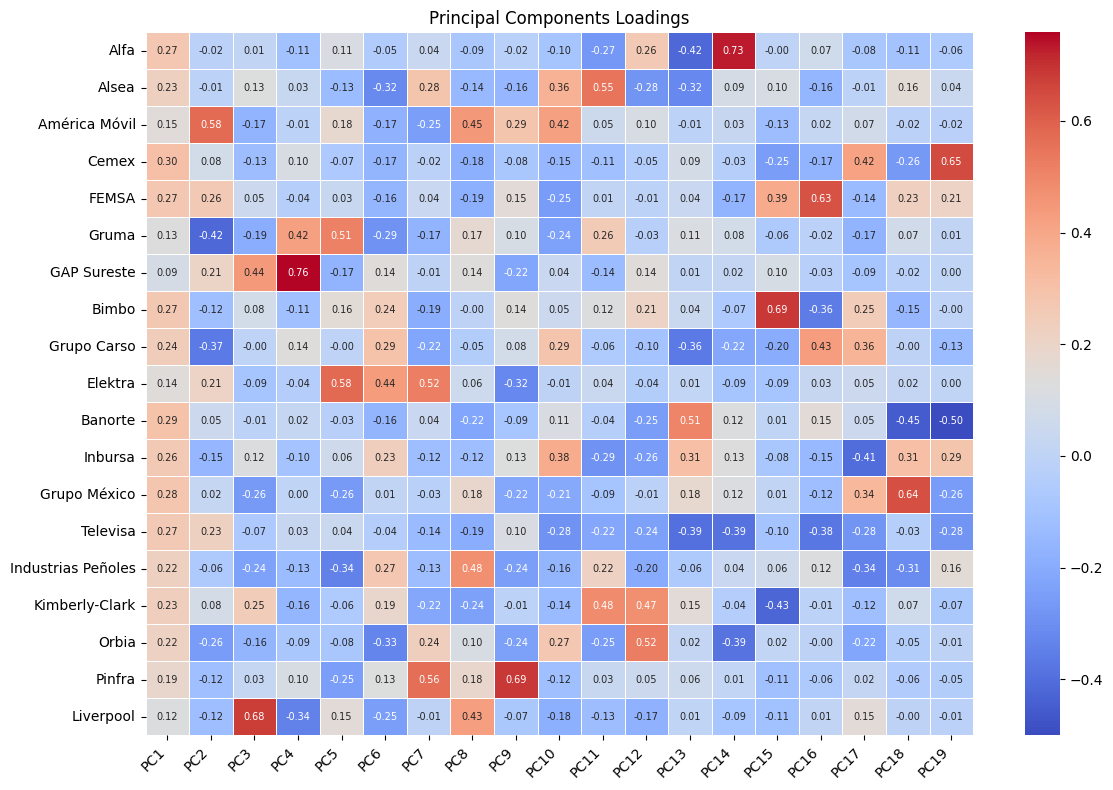

In [9]:
plt.figure(figsize=(12, 8))
sns.heatmap(loadings, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5, annot_kws={"size": 7})
plt.title('Principal Components Loadings')
plt.xticks(rotation=45, ha="right", fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.show()

In [10]:
projected_data = pd.DataFrame(projected_data, index=standardized_returns.index, columns=[f'PC{i+1}' for i in range(projected_data.shape[1])])
projected_data

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13,PC14,PC15,PC16,PC17,PC18,PC19
Date,,,,,,,,,,,,,,,,,,,
2000-10-05 05:00:00,-3.727847,1.207449,0.588831,-1.227402,-0.286715,-1.854767,2.583313,1.418233,-1.218838,-0.033788,1.757528,2.392646,5.258328,4.168071,2.059770,-0.605694,-0.513013,0.332885,2.822421
2000-10-06 05:00:00,-1.441834,-0.411842,0.725858,-0.840780,-0.009697,0.066042,-1.782887,-0.938679,-0.635171,-0.233068,1.977470,1.362349,-0.339359,-1.061757,-0.689909,-0.521874,-0.177980,-0.784558,0.001748
2000-10-09 05:00:00,-3.274462,0.017784,0.346237,-0.636205,1.532317,-1.156879,-4.974691,-2.206686,-6.015733,0.902152,0.456146,-0.955854,0.039850,-1.672050,1.275051,0.459464,-0.436288,-0.369627,0.076814
2000-10-10 05:00:00,-1.318303,1.172940,-0.152013,-0.329422,1.266069,-0.267358,-1.925315,-0.442068,-2.806647,0.298595,0.819624,-0.539112,0.485535,-1.969506,1.090737,1.147283,-0.098615,0.935153,-0.231746
2000-10-11 05:00:00,-2.456967,-1.090870,-1.618608,1.005719,-0.961043,-1.794575,0.811000,1.789013,-0.039412,-0.152668,-2.992360,-1.933967,-2.390381,1.156932,2.006050,-0.063775,0.849569,0.596002,0.060609
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-08-25 06:00:00,-1.278470,0.274788,0.666607,-0.469347,0.935067,-0.342619,-0.024213,-1.034690,0.738618,0.410492,-0.857051,0.784794,-0.306667,-0.669610,0.018055,-0.752971,0.463995,0.325579,0.146221
2025-08-26 06:00:00,-1.031149,-0.043482,-0.931675,0.052825,-0.170206,-0.801250,1.776665,1.036014,-1.067571,0.662397,-2.327492,-0.181861,0.425290,-0.575629,0.479974,-0.861538,-0.486732,-0.721747,0.692614
2025-08-27 06:00:00,2.575634,0.636069,0.047665,-0.117705,-0.585398,0.564883,-1.221101,-0.720571,-0.387409,-1.261495,1.758041,-1.089748,-1.889116,-0.532579,-0.907487,-1.077942,-1.653785,-0.607313,-1.395302


### IPC Index

In [3]:
# Descargar datos
import yfinance as yf

def download_stock(clave, nombre, start_date, end_date):
    print(f"Descargando datos de {nombre} ({clave})...")
    try:
        ticker = yf.Ticker(clave)
        df = ticker.history(start=start_date, end=end_date)
        if df is None or df.empty:
            print(f"Advertencia: no hay datos para {clave}")

        series = df['Close'].copy()
        # quitar tz si existe
        try:
            if hasattr(series.index, 'tz') and series.index.tz is not None:
                series.index = series.index.tz_convert(None)
        except Exception:
            try:
                series.index = series.index.tz_localize(None)
            except Exception:
                pass
        series.name = nombre

    except Exception as e:
        print(f"No se pudo descargar datos de {nombre}: {e}")
        series = pd.Series(dtype=float)
    return series

# Descargar IPC index
start_date = "1977-01-01"
end_date = pd.Timestamp.today().strftime('%Y-%m-%d')
ipc = download_stock('^MXX', 'IPC Index',start_date, end_date)
ipc.to_csv('ipc_index.csv')

Descargando datos de IPC Index (^MXX)...


In [11]:
ipc_index_df = pd.read_csv('ipc_index.csv')
ipc_index_df['Date'] = pd.to_datetime(ipc_index_df['Date'])
ipc_index_df.set_index('Date', inplace=True)
#ipci_df = ipci_df[['Close']]
#ipci_df = ipci_df.reindex(standardized_returns.index).dropna()
# Unir los datos del IPC con los datos proyectados
ipc_index_df

,IPC Index
Date,
1991-11-08 06:00:00,1418.800049
1991-11-11 06:00:00,1416.900024
1991-11-12 06:00:00,1445.400024
1991-11-13 06:00:00,1453.400024
1991-11-14 06:00:00,1459.300049
...,...
2025-08-26 06:00:00,58132.398438
2025-08-27 06:00:00,58647.519531
2025-08-28 06:00:00,59151.679688


In [12]:
# Intersección de fechas (Index con valores únicos)
a = ipc_index_df
b = projected_data
common = a.index.intersection(b.index)
# Seleccionar las filas con las fechas comunes.
ipci_a = a.loc[common]
projected_data_a = b.loc[common]

In [13]:
ipci_a

,IPC Index
Date,
2000-10-05 05:00:00,6368.669922
2000-10-06 05:00:00,6166.879883
2000-10-09 05:00:00,6141.529785
2000-10-10 05:00:00,6095.490234
2000-10-11 05:00:00,5946.930176
...,...
2025-08-25 06:00:00,58492.128906
2025-08-26 06:00:00,58132.398438
2025-08-27 06:00:00,58647.519531


In [10]:
ipci_df = pd.read_csv('SData_^MXX_1991-2024.csv')
ipci_df['Date'] = pd.to_datetime(ipci_df['Date'])
ipci_df.set_index('Date', inplace=True)
#ipci_df = ipci_df[['Close']]
#ipci_df = ipci_df.reindex(standardized_returns.index).dropna()
# Unir los datos del IPC con los datos proyectados
ipci_df

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
1991-11-08,1418.800049,1418.800049,1418.800049,1418.800049,1418.800049,0
1991-11-11,1416.900024,1416.900024,1416.900024,1416.900024,1416.900024,0
1991-11-12,1445.400024,1445.400024,1445.400024,1445.400024,1445.400024,0
1991-11-13,1453.400024,1453.400024,1453.400024,1453.400024,1453.400024,0
1991-11-14,1459.300049,1459.300049,1459.300049,1459.300049,1459.300049,0
...,...,...,...,...,...,...
2024-08-29,52511.050781,53302.308594,52476.851562,53138.960938,53138.960938,216583800
2024-08-30,52945.718750,53102.089844,52744.519531,52913.500000,52913.500000,464816500
2024-09-02,52133.890625,52737.121094,52091.589844,52493.378906,52493.378906,31027700


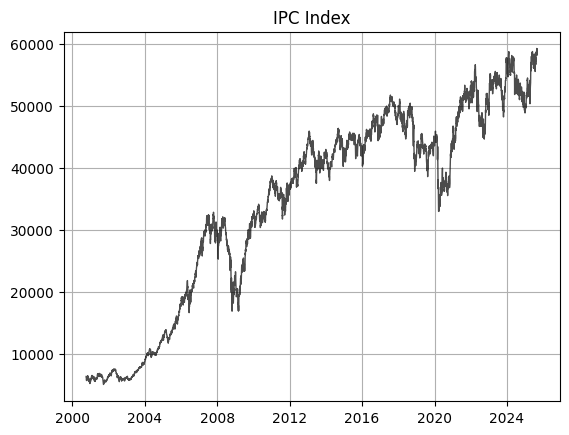

In [14]:
plt.plot( ipci_a, label='IPC', color='black', linewidth=1, alpha=0.7 )
plt.title('IPC Index')
plt.grid()

In [14]:
# Calcular retornos logarítmicos
log_returns = np.log(ipci_a['IPC Index'] / ipci_a['IPC Index'].shift(1)).dropna()

#Estandarizar retornos
std_rets_ipci = (log_returns - log_returns.mean()) / log_returns.std()
std_rets_ipci
#log_returns

Date
2000-10-06 05:00:00   -2.746735
2000-10-09 05:00:00   -0.377558
2000-10-10 05:00:00   -0.664905
2000-10-11 05:00:00   -2.111918
2000-10-12 05:00:00   -2.847058
                         ...   
2025-08-25 06:00:00   -1.081305
2025-08-26 06:00:00   -0.550523
2025-08-27 06:00:00    0.714389
2025-08-28 06:00:00    0.692246
2025-08-29 06:00:00   -0.664034
Name: IPC Index, Length: 6248, dtype: float64

In [31]:
# Calcular retornos logarítmicos
log_rets = np.log(ipci_df['Close'] / ipci_df['Close'].shift(1)).dropna()
#Estandarizar retornos
std_rets_ipci= (log_rets - log_rets.mean()) / log_rets.std()
std_rets_ipci = pd.DataFrame(std_rets_ipci, index=log_rets.index)
std_rets_ipci = std_rets_ipci[std_rets_ipci.index>='2000-10-05'] #standardized_returns.index.min()]

In [15]:
projected_data_a = projected_data_a[projected_data_a.index>'2000-10-06'] #
projected_data_a.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13,PC14,PC15,PC16,PC17,PC18,PC19
Date,,,,,,,,,,,,,,,,,,,
2000-10-06 05:00:00,-1.441834,-0.411842,0.725858,-0.840780,-0.009697,0.066042,-1.782887,-0.938679,-0.635171,-0.233068,1.977470,1.362349,-0.339359,-1.061757,-0.689909,-0.521874,-0.177980,-0.784558,0.001748
2000-10-09 05:00:00,-3.274462,0.017784,0.346237,-0.636205,1.532317,-1.156879,-4.974691,-2.206686,-6.015733,0.902152,0.456146,-0.955854,0.039850,-1.672050,1.275051,0.459464,-0.436288,-0.369627,0.076814
2000-10-10 05:00:00,-1.318303,1.172940,-0.152013,-0.329422,1.266069,-0.267358,-1.925315,-0.442068,-2.806647,0.298595,0.819624,-0.539112,0.485535,-1.969506,1.090737,1.147283,-0.098615,0.935153,-0.231746
2000-10-11 05:00:00,-2.456967,-1.090870,-1.618608,1.005719,-0.961043,-1.794575,0.811000,1.789013,-0.039412,-0.152668,-2.992360,-1.933967,-2.390381,1.156932,2.006050,-0.063775,0.849569,0.596002,0.060609
2000-10-12 05:00:00,-0.117203,0.254401,-5.577160,3.493374,-3.102143,2.646506,3.590928,-2.832442,4.089558,0.990065,0.835859,1.928406,0.003912,2.492767,-2.605981,-0.512591,-1.920163,-0.409844,-0.571092


### Comparacion IPC VS Componentes Principales

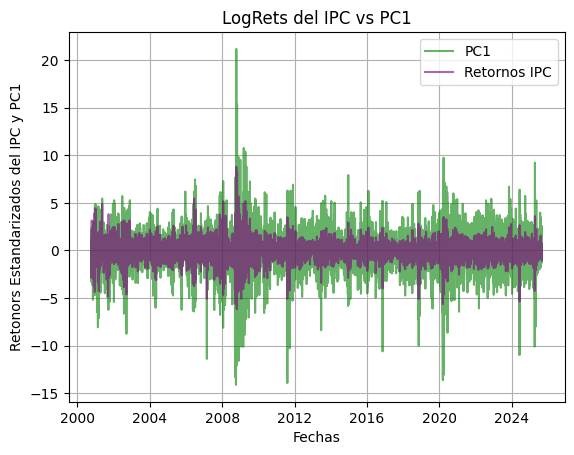

In [16]:
#plt.plot(projected_data['PC1'][:len(std_rets_ipci['Close'])], '-', markersize=2, alpha=0.6, label='PC1', color='green')
plt.plot(projected_data_a['PC1'], '-', markersize=2, alpha=0.6, label='PC1', color='green')
plt.plot(std_rets_ipci, '-', markersize=2, alpha=0.6 , label='Retornos IPC', color ='purple')
#plt.plot(log_returns['IPC Index'], '-', markersize=2, alpha=0.6 , label='Retornos IPC', color ='purple')
plt.title('LogRets del IPC vs PC1')
plt.xlabel('Fechas')
plt.ylabel('Retonors Estandarizados del IPC y PC1')
plt.legend()
plt.grid()

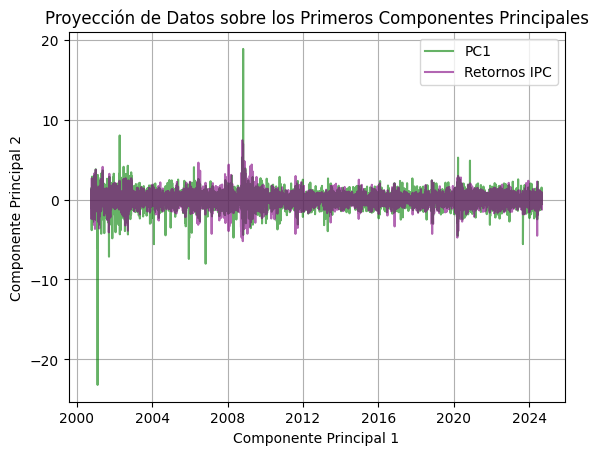

In [38]:
#plt.plot(projected_data['PC2'][:len(std_rets_ipci['Close'])], '-', markersize=2, alpha=0.6, label='PC2', color ='green')
plt.plot(projected_data['PC2'].loc[:'2024-09-04'], '-', markersize=2, alpha=0.6, label='PC1', color='green')
plt.plot(std_rets_ipci['Close'], '-', markersize=2, alpha=0.6 , label='Retornos IPC', color ='purple')
plt.title('Proyección de Datos sobre los Primeros Componentes Principales')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.legend()
plt.grid()

C:\Users\marti\AppData\Local\Temp\ipykernel_16012\3610342361.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


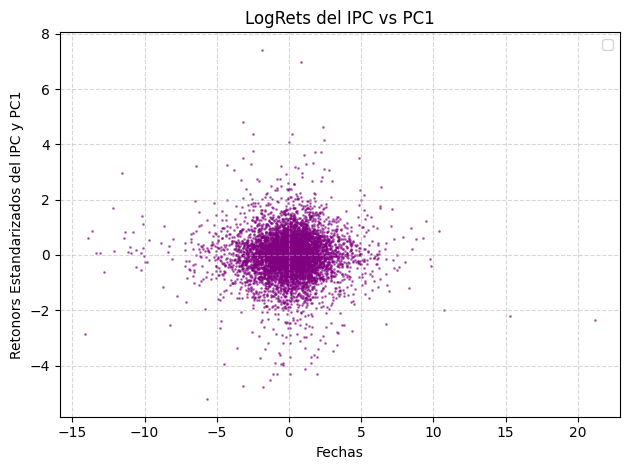

In [39]:
#plt.plot(projected_data['PC1'][:len(std_rets_ipci)], '-', markersize=2, alpha=0.6, label='PC1', color='green')
#plt.plot(std_rets_ipci['Close'], '-', markersize=2, alpha=0.6 , label='Retornos IPC', color ='purple')
plt.scatter(projected_data['PC1'][:len(std_rets_ipci)], std_rets_ipci['Close'], s=1, color='purple', alpha=0.5)
#plt.scatter(projected_data.index, projected_data['PC1'][:len(std_rets_ipci)], s=1, color='green', alpha=0.5)
plt.title('LogRets del IPC vs PC1')
plt.xlabel('Fechas')
plt.ylabel('Retonors Estandarizados del IPC y PC1')
plt.legend()
plt.grid(alpha=0.5, linestyle='--')
plt.tight_layout()
plt.show()

### De retornos a precios 

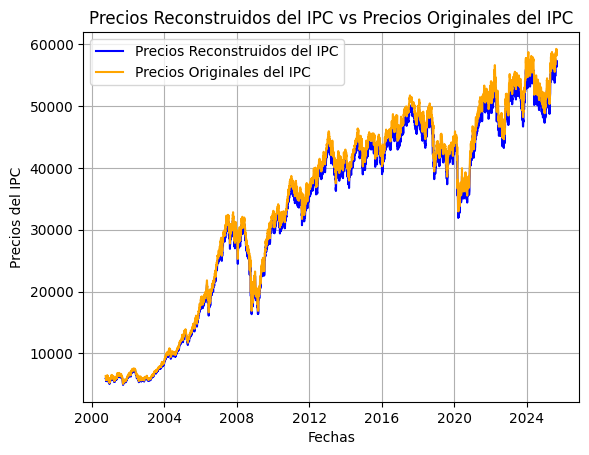

In [ ]:
import numpy as np
def log_returns_to_prices(initial_price, norm_log_rets, log_returns):
    """
    Convierte retornos logarítmicos a precios.
    :param initial_price: Precio inicial (float)
    :param log_returns: Lista de retornos logarítmicos (list o numpy array)
    :return: Lista de precios (numpy array)
    """
    # Convertir la lista de retornos logarítmicos a un array de numpy
    norm_log_rets = np.array(norm_log_rets)
    # Reescalar los retornos logarítmicos a su escala original
    log_rets = norm_log_rets * log_returns.std() + log_returns.mean()
    # Calcular los precios a partir de los retornos logarítmicos
    prices = initial_price * np.exp(np.cumsum(log_rets))
    return prices

precio_inicial = 6166.87 # Precio del IPC el 05-10-2000
precios_recons = log_returns_to_prices(precio_inicial, std_rets_ipci, log_returns)
precios_rec_df = pd.DataFrame(precios_recons, index=std_rets_ipci.index, columns=['Reconstructed IPC Prices'])
plt.plot(precios_rec_df,label='Precios Reconstruidos del IPC', color='blue')
plt.plot(ipci_a,label='Precios Originales del IPC', color='orange')
plt.title('Precios Reconstruidos del IPC vs Precios Originales del IPC')
plt.xlabel('Fechas')
plt.ylabel('Precios del IPC')
plt.legend()
plt.grid()
plt.show()

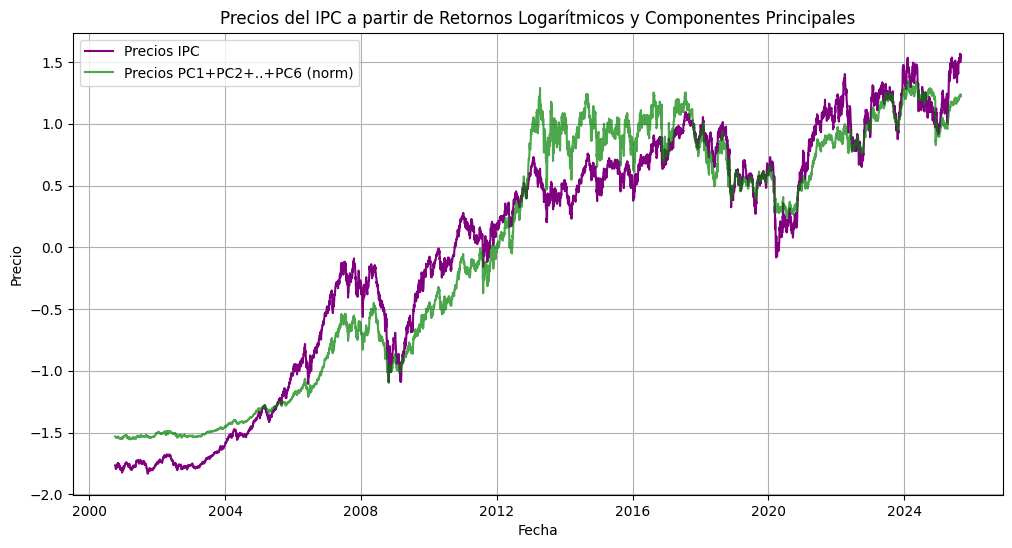

In [ ]:
import numpy as np
'''
def log_returns_to_prices(initial_price, log_returns):
    """
    Convierte retornos logarítmicos a precios.
    :param initial_price: Precio inicial (float)
    :param log_returns: Lista de retornos logarítmicos (list o numpy array)
    :return: Lista de precios (numpy array)
    """
    # Convertir la lista de retornos logarítmicos a un array de numpy
    log_returns = np.array(log_returns)
    # Reescalar los retornos logarítmicos a su escala original
    log_returns = log_returns * log_returns.std() + log_returns.mean()
    # Calcular los precios a partir de los retornos logarítmicos
    prices = initial_price * np.exp(np.cumsum(log_returns))
    return prices
'''

projected_data = projected_data_a
# Ejemplo de uso
#precio_inicial = 6675.27#ipci_df['Close'].loc['2000-01-04']
precio_inicial = 6166.87 #ipci_df['Close'].loc['2000-10-06']
#retornos_logaritmicos =  std_rets_ipci['Close'].values
# Convertir retornos logarítmicos a precios
precios_ipci = log_returns_to_prices(precio_inicial, std_rets_ipci, log_returns)
precios_PC1 = log_returns_to_prices(precio_inicial, projected_data['PC1'],log_returns)
precios_PC2 = log_returns_to_prices(precio_inicial, projected_data['PC2'],log_returns)
precios_PC3 = log_returns_to_prices(precio_inicial, projected_data['PC3'],log_returns)
precios_PC4 = log_returns_to_prices(precio_inicial, projected_data['PC4'],log_returns)
precios_PC5 = log_returns_to_prices(precio_inicial, projected_data['PC5'],log_returns)
precios_PC6 = log_returns_to_prices(precio_inicial, projected_data['PC6'],log_returns)
precios_PC7 = log_returns_to_prices(precio_inicial, projected_data['PC7'],log_returns)
precios_PC8 = log_returns_to_prices(precio_inicial, projected_data['PC8'],log_returns)
precios_PC9 = log_returns_to_prices(precio_inicial, projected_data['PC9'],log_returns)
precios_PC10 = log_returns_to_prices(precio_inicial, projected_data['PC10'],log_returns)


# Graficar los precios del IPC a partir de los retornos logarítmicos)
plt.figure(figsize=(12, 6))
plt.plot(std_rets_ipci.index, stdnorm(precios_ipci), label='Precios IPC', color='purple')
#*4-precio_inicial*3
plt.plot(projected_data.index, stdnorm(precios_PC1+precios_PC2+precios_PC3+precios_PC4+precios_PC5+precios_PC6+precios_PC7), label='Precios PC1+PC2+..+PC6 (norm)', alpha=0.7, color='green' )
#plt.plot(projected_data.index, stdnorm(precios_PC2), label='Precios PC2(norm)', alpha=0.7, color='brown')
#plt.plot(projected_data2.index, stdnorm(precios_PC3), label='Precios PC3(norm)', alpha=0.7, color='green')
plt.title('Precios del IPC a partir de Retornos Logarítmicos y Componentes Principales')
plt.xlabel('Fecha')
plt.ylabel('Precio')
plt.legend()
plt.grid()

C:\Users\marti\AppData\Local\Temp\ipykernel_37284\373188805.py:22: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


"\n#plt.plot(std_rets_ipci.index, precios_ipci*4-precio_inicial*3, label='Precios IPC')\nplt.plot(precios_ipci, precios_PC1[:len(precios_ipci)], label='Precios PC1', linestyle='None', marker='.', alpha=0.7)\n#plt.plot(projected_data.index, precios_PC2, label='Precios PC2', color='blue')\nplt.title('PC1 vs Precios IPC')\nplt.xlabel('IPC')\nplt.ylabel('PC1')\nplt.legend()\nplt.grid()\n"

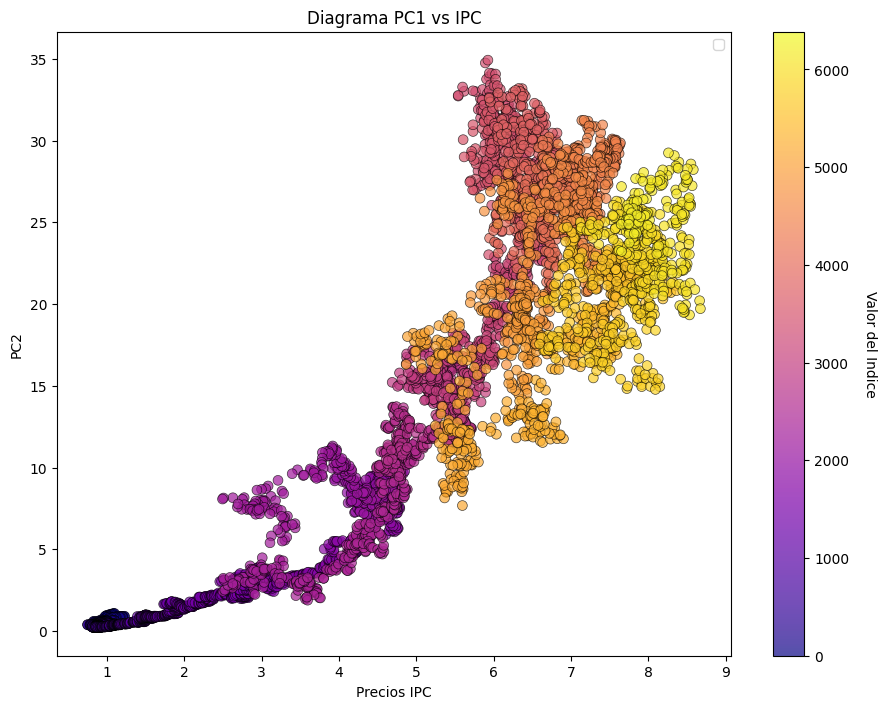

In [22]:
import matplotlib.colors as mcolors

plt.figure(figsize=(9, 7))
cmap = plt.cm.plasma
norm = mcolors.Normalize(vmin=0, vmax=len(precios_PC1) - 1)
scatter = plt.scatter(norm(precios_ipci), norm(precios_PC1[:len(precios_ipci)]),  
                      c=np.arange(len(precios_PC1[:len(precios_ipci)])), 
                      cmap=cmap, edgecolors='k', norm=norm, alpha=0.7,
                      linewidth=0.5, s=50)
#sns.regplot(x=norm(precios_PC1[:len(precios_ipci)]), y=norm(precios_ipci), scatter=False, color='red', line_kws={'linewidth':1.5})
plt.grid(True, linestyle='--', alpha=0.7)
plt.title(f'Diagrama PC1 vs IPC')
plt.tight_layout()
plt.ylabel('PC2')
plt.xlabel('Precios IPC')
# Coloca la leyenda al lado del gráfico
#plt.legend(loc='best')#, bbox_to_anchor=(1, 0.5))
 # Normalizar los valores de LogRets para el mapa de color
#norm = mcolors.Normalize(vmin=LogRets.min(), vmax=LogRets.max())
cbar = plt.colorbar(scatter)
cbar.set_label('Valor del Indice', rotation=270, labelpad=20)
plt.legend()
plt.grid()

'''
#plt.plot(std_rets_ipci.index, precios_ipci*4-precio_inicial*3, label='Precios IPC')
plt.plot(precios_ipci, precios_PC1[:len(precios_ipci)], label='Precios PC1', linestyle='None', marker='.', alpha=0.7)
#plt.plot(projected_data.index, precios_PC2, label='Precios PC2', color='blue')
plt.title('PC1 vs Precios IPC')
plt.xlabel('IPC')
plt.ylabel('PC1')
plt.legend()
plt.grid()
'''

In [23]:
import numpy as np
def log_returns_to_prices(initial_price, log_returns):
    """
    Convierte retornos logarítmicos a precios.
    :param initial_price: Precio inicial (float)
    :param log_returns: Lista de retornos logarítmicos (list o numpy array)
    :return: Lista de precios (numpy array)
    """
    # Convertir la lista de retornos logarítmicos a un array de numpy
    log_returns = np.array(log_returns)
    
    # Calcular los precios a partir de los retornos logarítmicos
    # np.cumsum(log_returns) calcula la suma acumulativa de los retornos logarítmicos
    prices = initial_price * np.exp(np.cumsum(log_returns))
    
    return prices


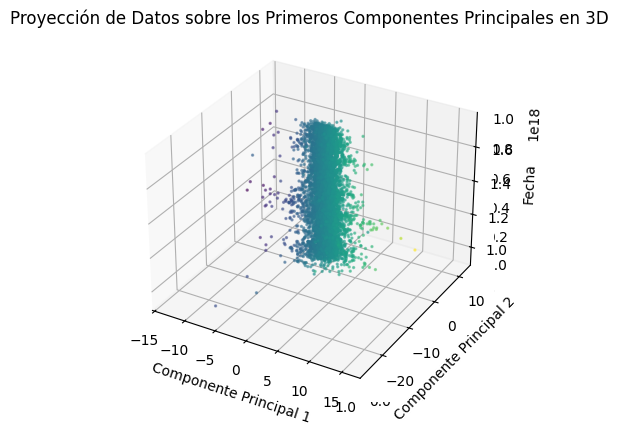

In [ ]:
fig = plt.figure()
ax = fig.add_subplot(projection='3d')
ax = fig.add_subplot(111, projection='3d')
projected_data.index = pd.to_datetime(projected_data.index,utc=True)
ax.scatter3D(projected_data['PC1'], projected_data['PC2'], projected_data.index.astype('int64'), 
             c=projected_data['PC1'], cmap='viridis', marker='o', s=2, alpha=0.5)
ax.set_xlabel('Componente Principal 1') 
ax.set_ylabel('Componente Principal 2')
ax.set_zlabel('Fecha')
plt.title('Proyección de Datos sobre los Primeros Componentes Principales en 3D')
plt.show()
# Graficar los primeros dos componentes principales

In [33]:
print(type(projected_data.index))

<class 'pandas.core.indexes.datetimes.DatetimeIndex'>
